In [ ]:
import os
import sys
import yaml
current_dir = os.path.dirname(os.path.abspath('.'))
project_root = os.path.abspath(os.path.join(current_dir, "../.."))
sys.path.insert(0, project_root)

In [2]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression
import yaml
from mlxtend.feature_selection import SequentialFeatureSelector as SFS

import warnings
warnings.filterwarnings('ignore')

In [3]:
with open(os.path.join("../config/config.yaml"), "r") as f:
    config = yaml.safe_load(f)
        
with open(os.path.join( "../config/pipeline.yaml"), "r") as f:
    config_pipe = yaml.safe_load(f)  

In [14]:
X_train = pd.read_parquet(
        os.path.join(
            config['init_path'],
            config['data']['feature_eng'],
            "X_train_feat_eng_pipeline1.parquet")
    )
y_train = pd.read_parquet(
        os.path.join(
            config['init_path'],
            config['data']['feature_eng'],
            "Y_train_feat_eng_pipeline1.parquet")
    )

In [15]:
sfs = SFS(
    estimator=LinearRegression(),
    k_features=X_train.shape[1]-1,  
    forward=True,  
    floating=False,  
    scoring='neg_mean_squared_error',
    cv=5, 
    n_jobs=-1
    )  

In [16]:
sfs_pipe = make_pipeline(sfs)
sfs_fit = sfs_pipe.fit(X_train, y_train)
    
results = pd.DataFrame.from_dict(sfs_pipe.named_steps['sequentialfeatureselector'].subsets_).T

In [17]:
results

,feature_idx,cv_scores,avg_score,feature_names
1,"(10,)","[-2634908636.817218, -2048566236.0665503, -273...",-2294266486.648765,"(num_dis_pipe__OverallQual,)"
2,"(2, 10)","[-2058126143.4233186, -1846144733.0757, -23588...",-1847000465.3744,"(num_con_1_pipe__GrLivArea, num_dis_pipe__Over..."
3,"(0, 2, 10)","[-1952536012.952046, -1628421579.703273, -2160...",-1675552066.787154,"(num_con_1_pipe__LotArea, num_con_1_pipe__GrLi..."
4,"(0, 2, 10, 16)","[-1779028361.0163856, -1438058147.9631426, -21...",-1555072225.986386,"(num_con_1_pipe__LotArea, num_con_1_pipe__GrLi..."
5,"(0, 2, 10, 16, 20)","[-1705939301.756908, -1290494324.7841587, -204...",-1470824412.952367,"(num_con_1_pipe__LotArea, num_con_1_pipe__GrLi..."
6,"(0, 2, 10, 16, 20, 21)","[-1615663943.1104207, -1264964838.6232688, -19...",-1415654789.719315,"(num_con_1_pipe__LotArea, num_con_1_pipe__GrLi..."
7,"(0, 2, 4, 10, 16, 20, 21)","[-1559705367.3317223, -1211994250.3002477, -19...",-1373381263.793632,"(num_con_1_pipe__LotArea, num_con_1_pipe__GrLi..."
8,"(0, 2, 4, 10, 16, 20, 21, 25)","[-1530607078.6581285, -1215183379.1476254, -18...",-1342757393.89708,"(num_con_1_pipe__LotArea, num_con_1_pipe__GrLi..."
9,"(0, 2, 4, 5, 10, 16, 20, 21, 25)","[-1503650084.5439148, -1201179915.409835, -182...",-1322975807.301851,"(num_con_1_pipe__LotArea, num_con_1_pipe__GrLi..."
10,"(0, 2, 4, 5, 10, 16, 20, 21, 25, 27)","[-1500137299.3951554, -1188780668.6933348, -18...",-1305335393.133863,"(num_con_1_pipe__LotArea, num_con_1_pipe__GrLi..."


In [18]:
metric_dict = sfs.get_metric_dict()
num_features = list(metric_dict.keys())
avg_scores = [metric_dict[k]['avg_score'] for k in num_features]
std_scores = [metric_dict[k]['std_dev'] for k in num_features]
cv_scores = [metric_dict[k]['cv_scores'] for k in num_features]  # Scores individuais de cada fold

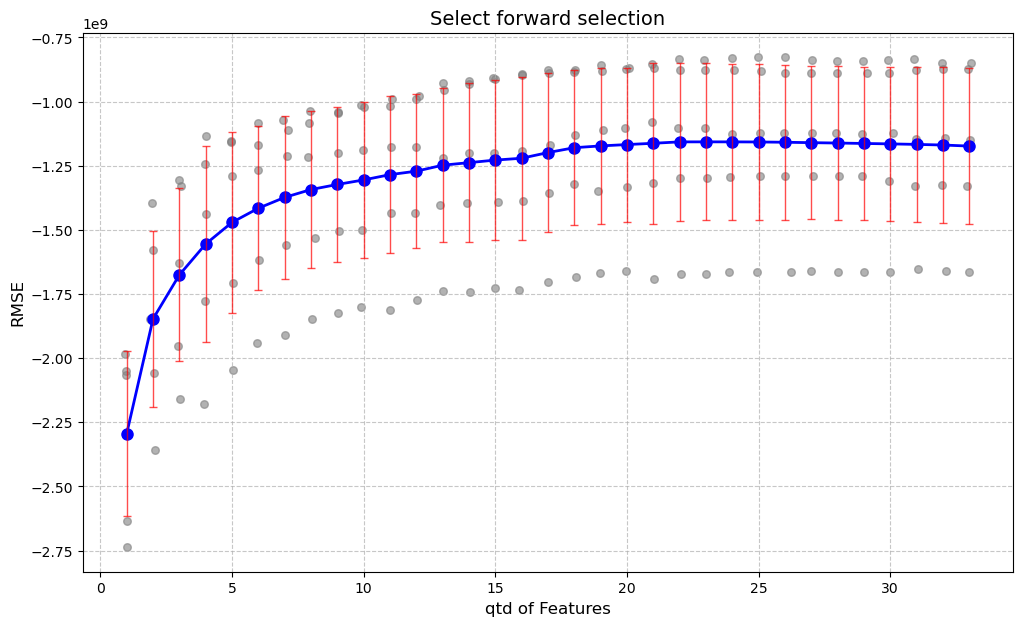

In [20]:
plt.figure(figsize=(12, 7))
plt.plot(
    num_features, 
    avg_scores, 
    marker='o', 
    linestyle='-', 
    color='b', 
    linewidth=2,
    markersize=8)

# Adicionar barras de erro (desvio padrão)
plt.errorbar(
    num_features, 
    avg_scores, 
    yerr=std_scores, 
    fmt='none', 
    ecolor='red', 
    elinewidth=1, 
    capsize=3, 
    alpha=0.7)

# Adicionar pontos individuais de cada fold da validação cruzada
for i, n in enumerate(num_features):
    # Espalhar os pontos horizontalmente para melhor visualização
    x_positions = np.random.normal(n, 0.05, size=len(cv_scores[i]))
    plt.scatter(x_positions, cv_scores[i], color='gray', alpha=0.6, s=30)

plt.xlabel('qtd of Features', fontsize=12)
plt.ylabel('RMSE', fontsize=12)
plt.title('Select forward selection', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)
